In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('UCI_Adult_Income_Dataset.csv')
df.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
5087,28,Private,142443,HS-grad,9,Never-married,Craft-repair,Own-child,White,Male,0,0,40,United-States,<=50K
35290,39,Self-emp-not-inc,107302,Bachelors,13,Married-civ-spouse,Craft-repair,Other-relative,White,Male,0,0,35,United-States,>50K.
35085,48,Private,56071,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K.
17607,26,Private,244372,HS-grad,9,Married-civ-spouse,Adm-clerical,Wife,White,Female,0,0,52,United-States,>50K
17150,36,Private,272090,Bachelors,13,Divorced,Prof-specialty,Unmarried,White,Female,0,0,45,El-Salvador,<=50K


In [22]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [4]:
# from this we can conclude that there are null values in only 3 columns --> workclass, occupation,native-country

In [5]:
df['workclass'].value_counts()  

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

In [6]:
df['workclass'].isnull().sum()

np.int64(963)

In [7]:
(df['workclass'] == '?').sum()

np.int64(1836)

In [8]:
df.replace('?', np.nan, inplace=True)

In [9]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [10]:
# Explore numerical columns
df[cat_cols].describe()

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,46043,48842,48842,46033,48842,48842,48842,47985,48842
unique,8,16,7,14,6,5,2,41,4
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,24720


In [11]:
(df.isnull().sum()/len(df))*100

age               0.000000
workclass         5.730724
fnlwgt            0.000000
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        5.751198
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    1.754637
income            0.000000
dtype: float64

In [12]:
df['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', nan, 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

## Filling Null Values

In [13]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(strategy='most_frequent')
df[['workclass','occupation','native-country']]=si.fit_transform(df[['workclass','occupation','native-country']])

In [14]:
df.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
35756,29,Private,31659,Some-college,10,Never-married,Craft-repair,Not-in-family,White,Male,2202,0,45,United-States,<=50K.
10398,43,Private,397963,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,594,0,16,United-States,<=50K
46727,37,Private,280549,Bachelors,13,Never-married,Adm-clerical,Other-relative,White,Female,0,0,40,United-States,<=50K.
40050,55,Private,194371,HS-grad,9,Married-civ-spouse,Sales,Wife,White,Female,0,0,40,Canada,>50K.
40572,30,Private,307353,HS-grad,9,Never-married,Other-service,Unmarried,Black,Female,0,0,35,United-States,<=50K.


In [15]:
(df.isnull().sum()/len(df))*100

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education-num     0.0
marital-status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital-gain      0.0
capital-loss      0.0
hours-per-week    0.0
native-country    0.0
income            0.0
dtype: float64

## Removal of Duplicated Rows

In [16]:
df.duplicated().sum()

np.int64(29)

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.shape

(48813, 15)

## Analysis on Numerical Columns

In [19]:
df[num_cols].describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48813.000000,4.881300e+04,48813.000000,48813.000000,48813.000000,48813.000000
mean,38.647348,1.896679e+05,10.078688,1079.708705,87.554299,40.425051
std,13.709005,1.056062e+05,2.570257,7454.185982,403.118605,12.390954
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781400e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376200e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


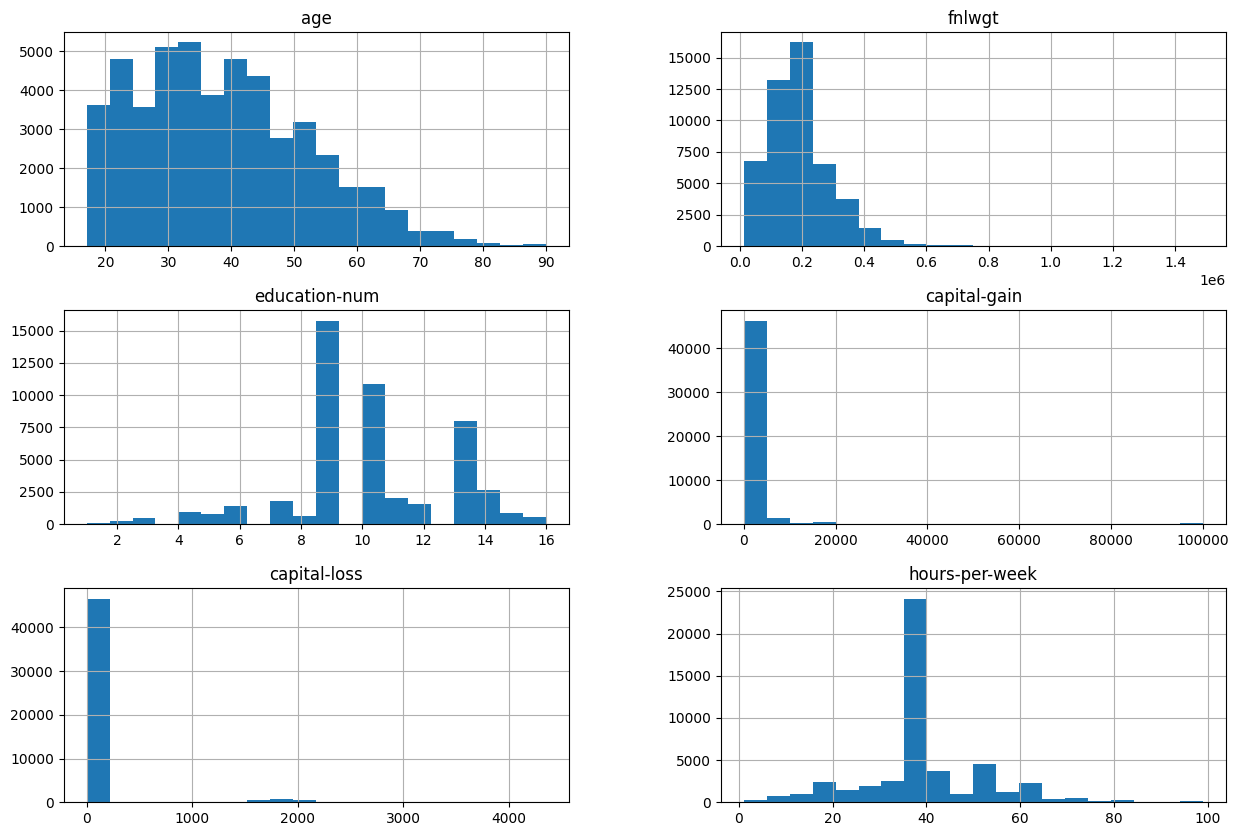

In [20]:
df[num_cols].hist(figsize=(15,10), bins=20)
plt.show()

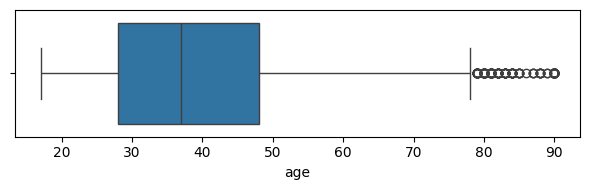

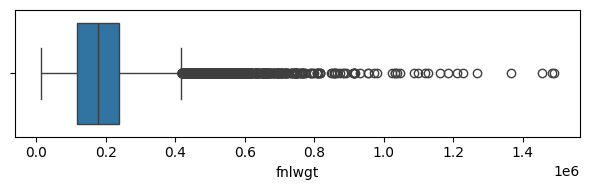

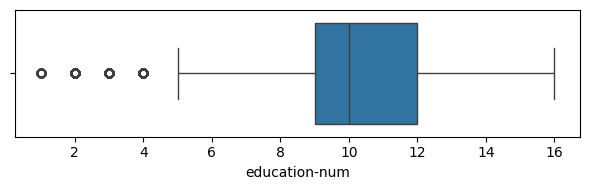

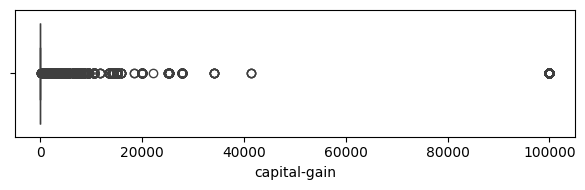

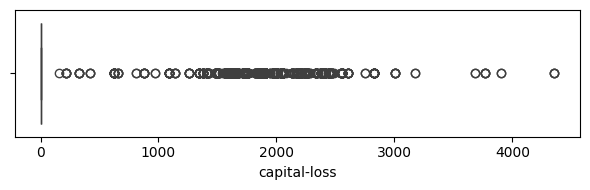

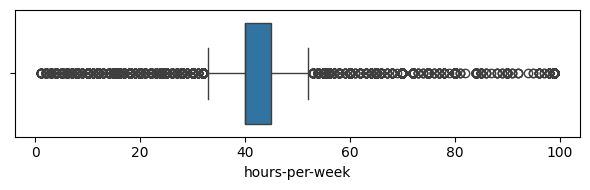

In [21]:
import seaborn as sns
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.tight_layout()
    plt.show()

## Bivariate Analysis


<!-- numerical column analysis -->

In [24]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


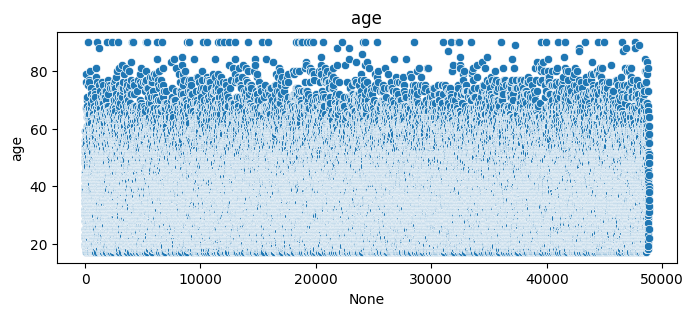

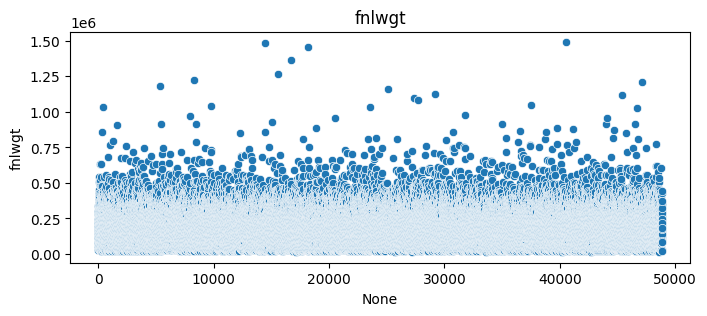

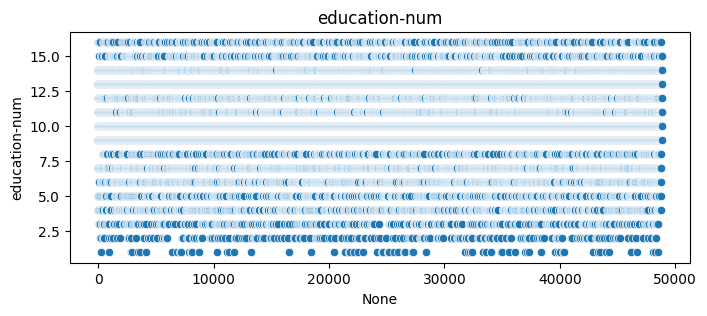

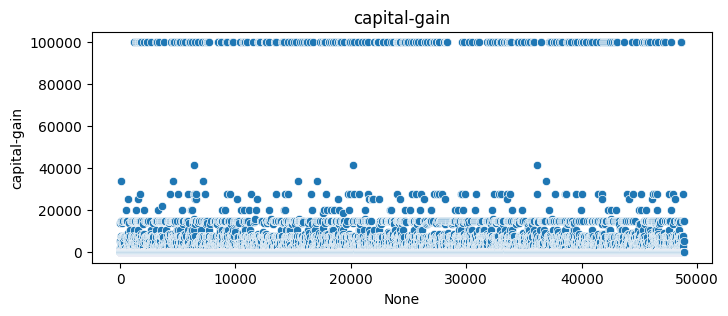

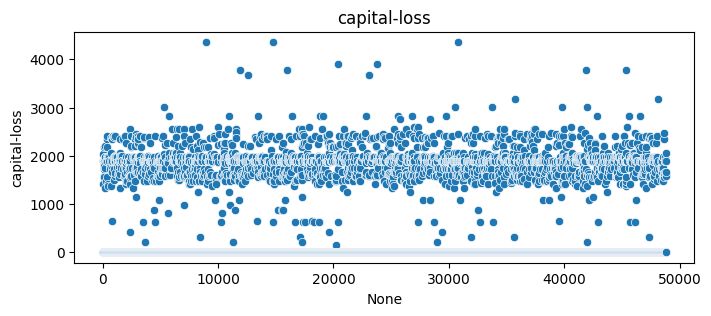

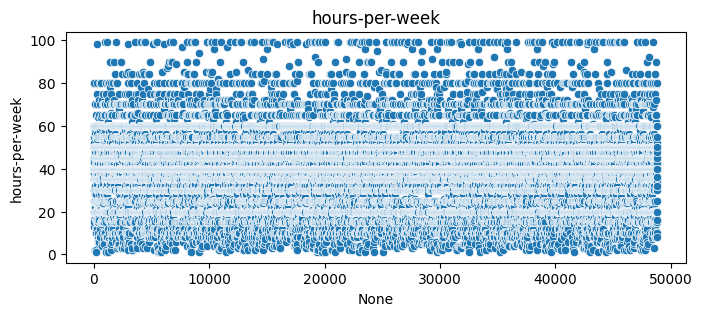

In [29]:
for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.scatterplot(x=df.index, y=df[col])
    plt.title(col)
    plt.show()
    

<!-- categorical columns and income(target) -->

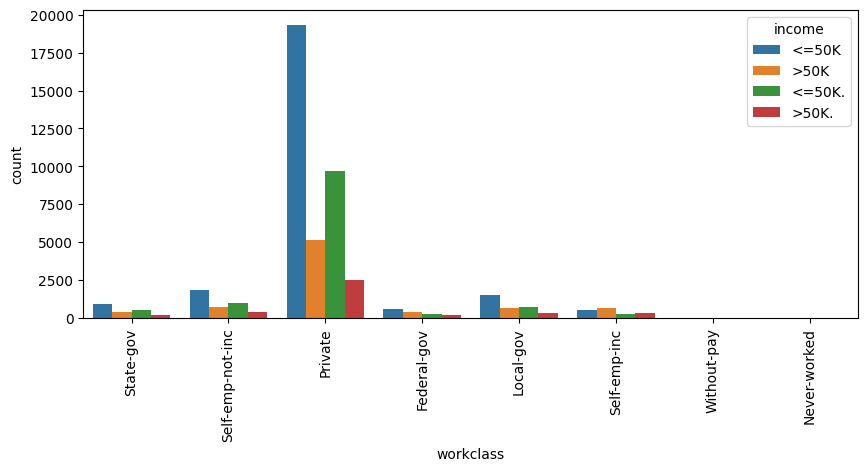

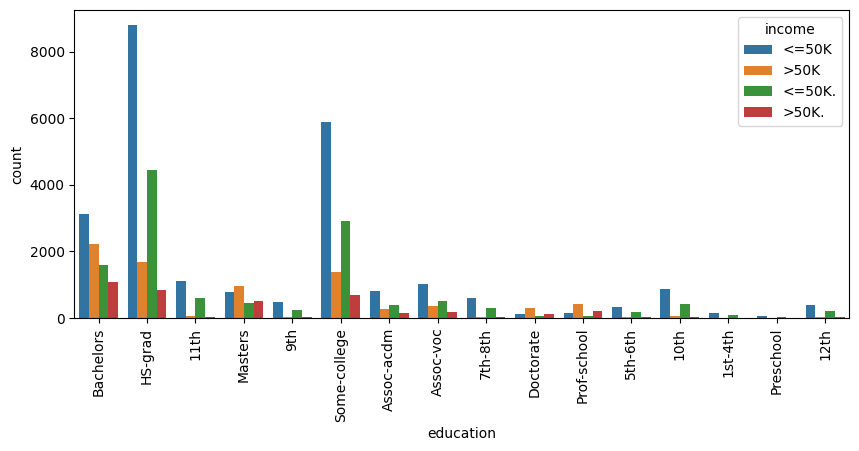

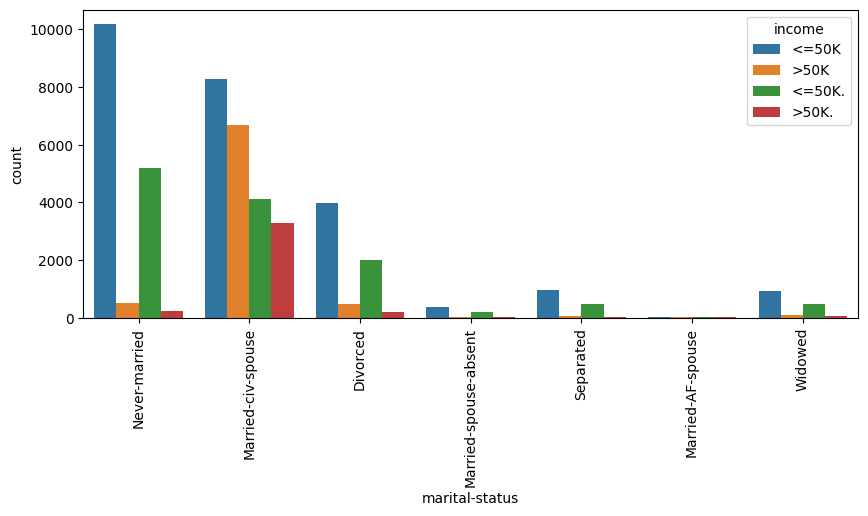

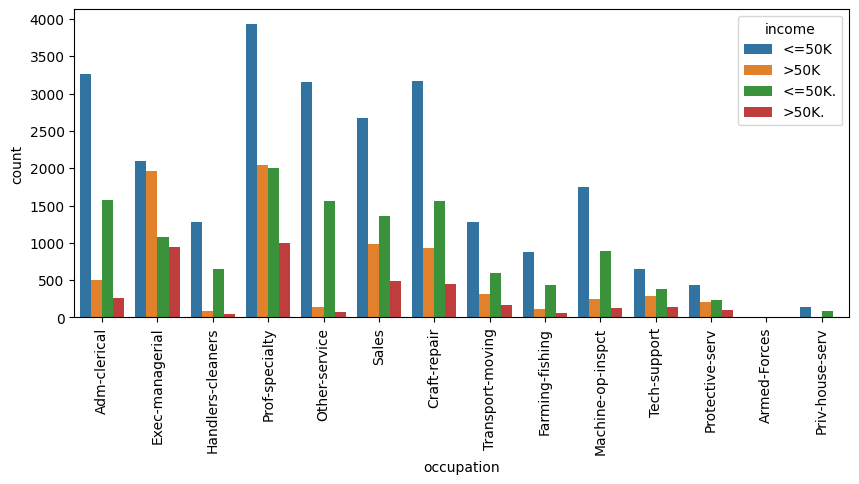

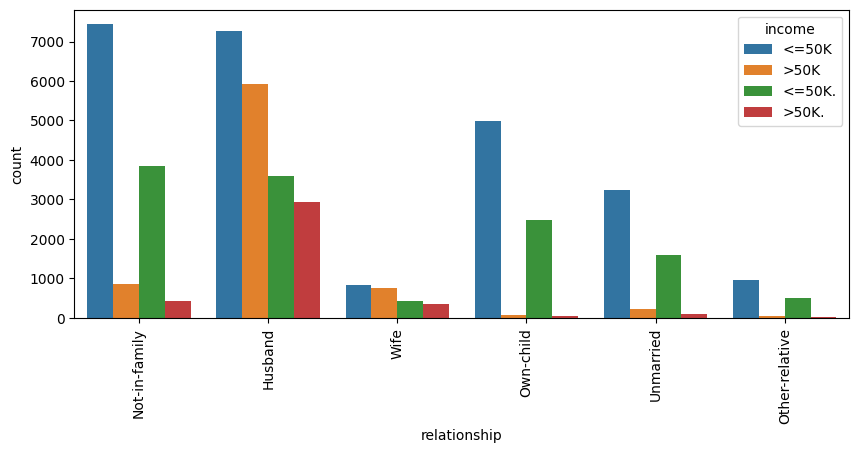

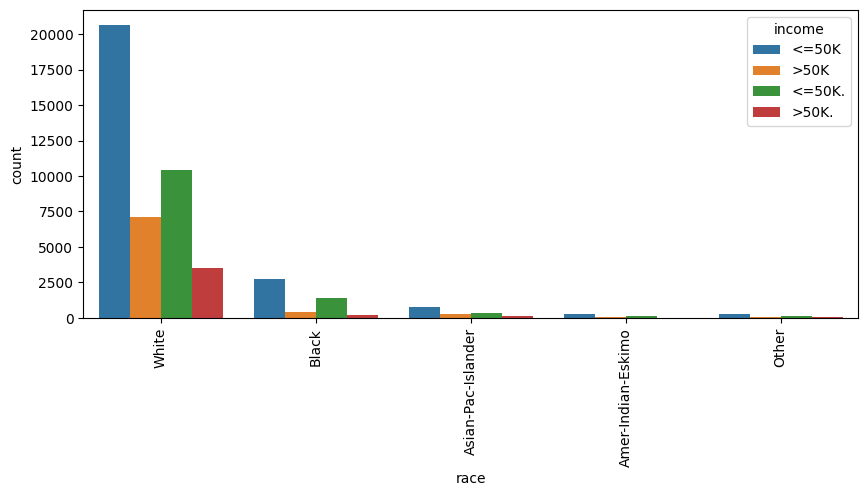

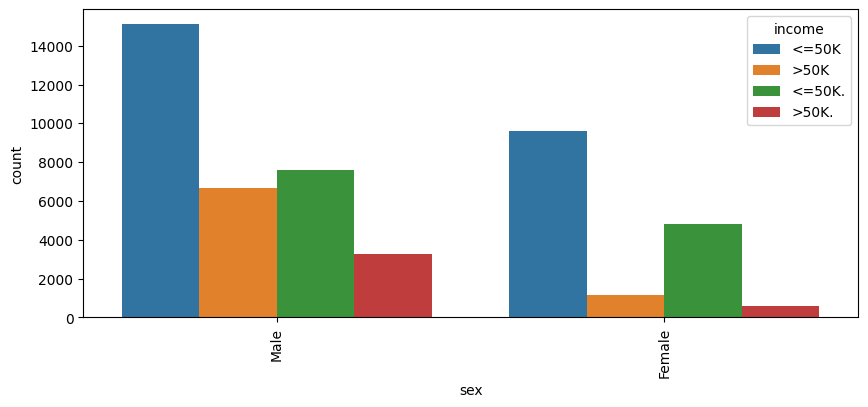

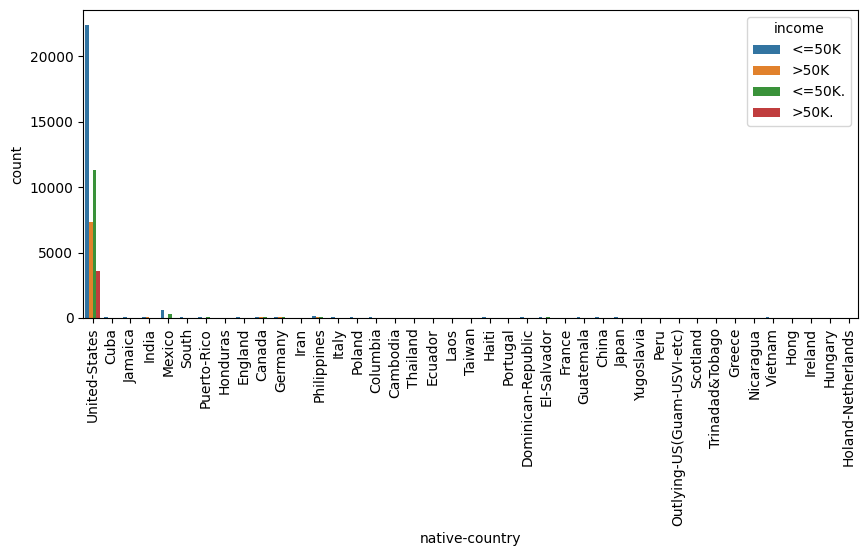

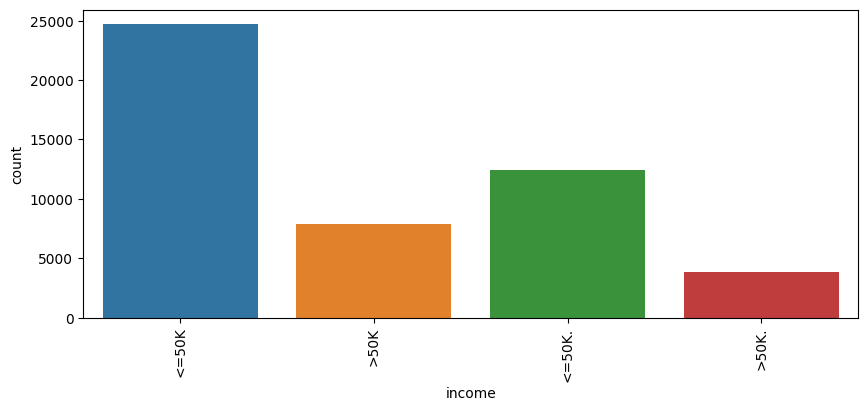

In [36]:
for col in cat_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(data=df, x=col, hue='income')
    plt.xticks(rotation=90)
    plt.show()

In [37]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Feature Encoding

In [ ]:
cat_cols
 

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')